Just merging all the years together to make a working set.

In [34]:
import pandas as pd
import os

folder_path = r"C:\Users\priva\OneDrive\Documents\Honors Project\Data\Medicare"
save_path = r"C:\Users\priva\OneDrive\Documents\Honors Project\Data"

all_dfs = []

for year in range(2013, 2024):
    file_path = os.path.join(folder_path, f"{year} medicare.xlsx")
    if os.path.exists(file_path):
        df = pd.read_excel(file_path)
        df["Year"] = year
        all_dfs.append(df)

combined_df = pd.concat(all_dfs, ignore_index=True)

working_file = os.path.join(save_path, "medicare_working_dataset.csv")
combined_df.to_csv(working_file, index=False)

sample_df = combined_df.sample(n=5000, random_state=1)
sample_file = os.path.join(save_path, "medicare_sample_dataset.csv")
sample_df.to_csv(sample_file, index=False)




In [35]:
import pandas as pd
import os

# paths
save_path = r"C:\Users\priva\OneDrive\Documents\Honors Project\Data"
working_file = os.path.join(save_path, "medicare_working_dataset.csv")

# load working dataset
df = pd.read_csv(working_file)

# quick structure checks
print(df.shape)
print(df.columns.tolist())

# basic missingness (top 15)
print((df.isna().mean().sort_values(ascending=False).head(15) * 100).round(2))

# key counts
print("years:", df["Year"].nunique())
print("hospitals (CCN):", df["Rndrng_Prvdr_CCN"].nunique())
print("drgs:", df["DRG_Cd"].nunique())
print("states:", df["Rndrng_Prvdr_State_Abrvtn"].nunique())

# outcome summaries
print(df["Avg_Submtd_Cvrd_Chrg"].describe())
print(df["Avg_Tot_Pymt_Amt"].describe())
print(df["Avg_Mdcr_Pymt_Amt"].describe())

# check duplicates on hospital x drg x year
k = ["Rndrng_Prvdr_CCN", "DRG_Cd", "Year"]
print("duplicate hospital-drg-year rows:", df.duplicated(k).sum())

# top DRGs by hospital coverage
top_drgs = (
    df.groupby("DRG_Desc")["Rndrng_Prvdr_CCN"]
      .nunique()
      .sort_values(ascending=False)
      .head(25)
)
print(top_drgs)

# top states by row count
top_states = df["Rndrng_Prvdr_State_Abrvtn"].value_counts().head(20)
print(top_states)


(1985253, 16)
['Rndrng_Prvdr_CCN', 'Rndrng_Prvdr_Org_Name', 'Rndrng_Prvdr_City', 'Rndrng_Prvdr_St', 'Rndrng_Prvdr_State_FIPS', 'Rndrng_Prvdr_Zip5', 'Rndrng_Prvdr_State_Abrvtn', 'Rndrng_Prvdr_RUCA', 'Rndrng_Prvdr_RUCA_Desc', 'DRG_Cd', 'DRG_Desc', 'Tot_Dschrgs', 'Avg_Submtd_Cvrd_Chrg', 'Avg_Tot_Pymt_Amt', 'Avg_Mdcr_Pymt_Amt', 'Year']
Rndrng_Prvdr_RUCA            0.05
Rndrng_Prvdr_RUCA_Desc       0.05
Rndrng_Prvdr_City            0.00
Rndrng_Prvdr_CCN             0.00
Rndrng_Prvdr_St              0.00
Rndrng_Prvdr_State_FIPS      0.00
Rndrng_Prvdr_Zip5            0.00
Rndrng_Prvdr_Org_Name        0.00
Rndrng_Prvdr_State_Abrvtn    0.00
DRG_Cd                       0.00
DRG_Desc                     0.00
Tot_Dschrgs                  0.00
Avg_Submtd_Cvrd_Chrg         0.00
Avg_Tot_Pymt_Amt             0.00
Avg_Mdcr_Pymt_Amt            0.00
dtype: float64
years: 11
hospitals (CCN): 3497
drgs: 684
states: 51
count    1.985253e+06
mean     6.680922e+04
std      8.522564e+04
min      1.281417e+03


In [36]:
import numpy as np

# keep only needed cols and fix types
num_cols = ["Tot_Dschrgs", "Avg_Submtd_Cvrd_Chrg", "Avg_Tot_Pymt_Amt", "Avg_Mdcr_Pymt_Amt"]
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors="coerce")

# drop obvious bad rows
df = df[df["Avg_Submtd_Cvrd_Chrg"] > 0].copy()
df = df[df["Tot_Dschrgs"] > 0].copy()

# add logs (main outcomes)
df["log_charge"] = np.log(df["Avg_Submtd_Cvrd_Chrg"])
df["log_tot_pay"] = np.log(df["Avg_Tot_Pymt_Amt"].clip(lower=1))
df["log_mdcr_pay"] = np.log(df["Avg_Mdcr_Pymt_Amt"].clip(lower=1))

# quick ratio features
df["charge_to_totpay"] = df["Avg_Submtd_Cvrd_Chrg"] / df["Avg_Tot_Pymt_Amt"].replace(0, np.nan)
df["totpay_to_mdcr"] = df["Avg_Tot_Pymt_Amt"] / df["Avg_Mdcr_Pymt_Amt"].replace(0, np.nan)

print(df.shape)
print(df[["log_charge","log_tot_pay","log_mdcr_pay","charge_to_totpay","totpay_to_mdcr"]].describe())

# biggest charge outliers (overall)
outliers = df.sort_values("Avg_Submtd_Cvrd_Chrg", ascending=False).head(20)
print(outliers[["Year","Rndrng_Prvdr_State_Abrvtn","Rndrng_Prvdr_CCN","DRG_Cd","DRG_Desc","Tot_Dschrgs","Avg_Submtd_Cvrd_Chrg","Avg_Tot_Pymt_Amt","Avg_Mdcr_Pymt_Amt"]])

# max/min ratio by DRG (variation scan)
var = df.groupby("DRG_Desc")["Avg_Submtd_Cvrd_Chrg"].agg(["min","median","max","count"])
var["max_min_ratio"] = var["max"] / var["min"]
print(var.sort_values("max_min_ratio", ascending=False).head(20))


(1985253, 21)
         log_charge   log_tot_pay  log_mdcr_pay  charge_to_totpay  \
count  1.985253e+06  1.985253e+06  1.985253e+06      1.985253e+06   
mean   1.073052e+01  9.353351e+00  9.149499e+00      4.505747e+00   
std    8.194956e-01  6.673787e-01  7.149068e-01      2.397997e+00   
min    7.155722e+00  6.970815e+00  0.000000e+00      1.157366e-01   
25%    1.014432e+01  8.848730e+00  8.614650e+00      2.913890e+00   
50%    1.066690e+01  9.248240e+00  9.064299e+00      3.959446e+00   
75%    1.124971e+01  9.726953e+00  9.554897e+00      5.506535e+00   
max    1.615914e+01  1.354336e+01  1.352980e+01      3.915664e+01   

       totpay_to_mdcr  
count    1.985251e+06  
mean     1.238745e+00  
std      2.400056e-01  
min      1.000000e+00  
25%      1.115275e+00  
50%      1.194718e+00  
75%      1.304383e+00  
max      8.688334e+01  
         Year Rndrng_Prvdr_State_Abrvtn  Rndrng_Prvdr_CCN  DRG_Cd  \
1953428  2023                        PA            390164      18   
1807417  2

In [37]:
# pick common, high-volume DRGs
selected_drgs = [
"SEPTICEMIA OR SEVERE SEPSIS WITHOUT MV >96 HOURS WITH MCC",
"SEPTICEMIA OR SEVERE SEPSIS WITHOUT MV >96 HOURS WITHOUT MCC",
"HEART FAILURE AND SHOCK WITH MCC",
"SIMPLE PNEUMONIA AND PLEURISY WITH MCC",
"CHRONIC OBSTRUCTIVE PULMONARY DISEASE WITH MCC",
"RENAL FAILURE WITH CC",
"MISCELLANEOUS DISORDERS OF NUTRITION, METABOLISM, FLUIDS AND ELECTROLYTES WITHOUT MCC",
"MAJOR HIP AND KNEE JOINT REPLACEMENT OR REATTACHMENT OF LOWER EXTREMITY WITHOUT MCC",
"GASTROINTESTINAL HEMORRHAGE WITH CC",
"CARDIAC ARRHYTHMIA AND CONDUCTION DISORDERS WITH CC"
]

core = df[df["DRG_Desc"].isin(selected_drgs)].copy()

print(core.shape)
print(core["DRG_Desc"].value_counts())

# save core working dataset
core_file = os.path.join(save_path, "medicare_core_working.csv")
core.to_csv(core_file, index=False)


(260405, 21)
DRG_Desc
SEPTICEMIA OR SEVERE SEPSIS WITHOUT MV >96 HOURS WITH MCC                                30619
HEART FAILURE AND SHOCK WITH MCC                                                         29461
SEPTICEMIA OR SEVERE SEPSIS WITHOUT MV >96 HOURS WITHOUT MCC                             27366
SIMPLE PNEUMONIA AND PLEURISY WITH MCC                                                   27143
RENAL FAILURE WITH CC                                                                    25166
MAJOR HIP AND KNEE JOINT REPLACEMENT OR REATTACHMENT OF LOWER EXTREMITY WITHOUT MCC      25118
CHRONIC OBSTRUCTIVE PULMONARY DISEASE WITH MCC                                           24984
MISCELLANEOUS DISORDERS OF NUTRITION, METABOLISM, FLUIDS AND ELECTROLYTES WITHOUT MCC    24675
GASTROINTESTINAL HEMORRHAGE WITH CC                                                      24278
CARDIAC ARRHYTHMIA AND CONDUCTION DISORDERS WITH CC                                      21595
Name: count, dtype: int64


In [38]:
# variation by DRG
v = core.groupby("DRG_Desc")["Avg_Submtd_Cvrd_Chrg"].agg(
    min="min",
    median="median",
    max="max",
    count="count"
)

v["max_min_ratio"] = v["max"] / v["min"]
print(v.sort_values("max_min_ratio", ascending=False))


# variation by hospital within DRG
hosp_var = (
    core.groupby(["DRG_Desc", "Rndrng_Prvdr_CCN"])["Avg_Submtd_Cvrd_Chrg"]
    .median()
    .reset_index()
)

spread = hosp_var.groupby("DRG_Desc")["Avg_Submtd_Cvrd_Chrg"].agg(
    min="min",
    median="median",
    max="max"
)

spread["max_min_ratio"] = spread["max"] / spread["min"]
print(spread.sort_values("max_min_ratio", ascending=False))


                                                            min        median  \
DRG_Desc                                                                        
CHRONIC OBSTRUCTIVE PULMONARY DISEASE WITH MCC      4273.090909  31381.765883   
MISCELLANEOUS DISORDERS OF NUTRITION, METABOLIS...  3199.058824  21572.341463   
MAJOR HIP AND KNEE JOINT REPLACEMENT OR REATTAC...  4197.947368  57054.155872   
SEPTICEMIA OR SEVERE SEPSIS WITHOUT MV >96 HOUR...  4917.166667  29753.470355   
HEART FAILURE AND SHOCK WITH MCC                    5534.000000  35958.651724   
SEPTICEMIA OR SEVERE SEPSIS WITHOUT MV >96 HOUR...  6861.600000  49451.837838   
RENAL FAILURE WITH CC                               4608.000000  25523.755842   
SIMPLE PNEUMONIA AND PLEURISY WITH MCC              6631.545455  36989.666667   
GASTROINTESTINAL HEMORRHAGE WITH CC                 5911.000000  30264.417873   
CARDIAC ARRHYTHMIA AND CONDUCTION DISORDERS WIT...  4847.090909  23498.684211   

                           

In [39]:
# state-level median charges by DRG
state_med = (
    core.groupby(["DRG_Desc", "Rndrng_Prvdr_State_Abrvtn"])["Avg_Submtd_Cvrd_Chrg"]
    .median()
    .reset_index()
)

state_spread = state_med.groupby("DRG_Desc")["Avg_Submtd_Cvrd_Chrg"].agg(
    min="min",
    median="median",
    max="max"
)

state_spread["max_min_ratio"] = state_spread["max"] / state_spread["min"]
print(state_spread.sort_values("max_min_ratio", ascending=False))


# urban vs rural check
ruca = core.groupby("Rndrng_Prvdr_RUCA_Desc")["Avg_Submtd_Cvrd_Chrg"].median()
print(ruca.sort_values())


# save final core dataset used for modeling
final_core_file = os.path.join(save_path, "medicare_core_clean.csv")
core.to_csv(final_core_file, index=False)


                                                             min  \
DRG_Desc                                                           
CARDIAC ARRHYTHMIA AND CONDUCTION DISORDERS WIT...   8802.263158   
HEART FAILURE AND SHOCK WITH MCC                    14142.772727   
GASTROINTESTINAL HEMORRHAGE WITH CC                 11137.637123   
SEPTICEMIA OR SEVERE SEPSIS WITHOUT MV >96 HOUR...  20556.158369   
CHRONIC OBSTRUCTIVE PULMONARY DISEASE WITH MCC      12944.991072   
SIMPLE PNEUMONIA AND PLEURISY WITH MCC              14785.258065   
RENAL FAILURE WITH CC                               10644.680412   
SEPTICEMIA OR SEVERE SEPSIS WITHOUT MV >96 HOUR...  11884.222121   
MISCELLANEOUS DISORDERS OF NUTRITION, METABOLIS...   8992.022727   
MAJOR HIP AND KNEE JOINT REPLACEMENT OR REATTAC...  24028.375000   

                                                          median  \
DRG_Desc                                                           
CARDIAC ARRHYTHMIA AND CONDUCTION DISORDERS WIT

In [40]:
# standardize hospital id column name for merging later
core["CCN"] = core["Rndrng_Prvdr_CCN"].astype(str)

# keep only columns we actually need going forward
core = core[[
    "CCN",
    "Rndrng_Prvdr_Org_Name",
    "Rndrng_Prvdr_State_Abrvtn",
    "Rndrng_Prvdr_RUCA_Desc",
    "DRG_Cd",
    "DRG_Desc",
    "Tot_Dschrgs",
    "Avg_Submtd_Cvrd_Chrg",
    "Avg_Tot_Pymt_Amt",
    "Avg_Mdcr_Pymt_Amt",
    "Year",
    "log_charge",
    "log_tot_pay",
    "log_mdcr_pay"
]].copy()

print(core.shape)
print(core.head())

# save merge-ready dataset
merge_ready_file = os.path.join(save_path, "medicare_core_merge_ready.csv")
core.to_csv(merge_ready_file, index=False)


(260405, 14)
      CCN             Rndrng_Prvdr_Org_Name Rndrng_Prvdr_State_Abrvtn  \
30  10001  Southeast Alabama Medical Center                        AL   
33  10001  Southeast Alabama Medical Center                        AL   
66  10001  Southeast Alabama Medical Center                        AL   
74  10001  Southeast Alabama Medical Center                        AL   
87  10001  Southeast Alabama Medical Center                        AL   

                               Rndrng_Prvdr_RUCA_Desc  DRG_Cd  \
30  Metropolitan area core: primary flow within an...     190   
33  Metropolitan area core: primary flow within an...     193   
66  Metropolitan area core: primary flow within an...     291   
74  Metropolitan area core: primary flow within an...     309   
87  Metropolitan area core: primary flow within an...     378   

                                             DRG_Desc  Tot_Dschrgs  \
30     CHRONIC OBSTRUCTIVE PULMONARY DISEASE WITH MCC           64   
33             SI

In [41]:
import pandas as pd
import os

save_path = r"C:\Users\priva\OneDrive\Documents\Honors Project\Data"

core_file = os.path.join(save_path, "medicare_core_merge_ready.csv")
hosp_file = r"C:\Users\priva\OneDrive\Documents\Honors Project\Data\Hospital_General_Information.csv.xlsx"

core = pd.read_csv(core_file, dtype={"CCN": str})
hosp = pd.read_excel(hosp_file, dtype={"Facility ID": str})

# rename for merge
hosp = hosp.rename(columns={"Facility ID": "CCN"})

# keep needed columns
hosp = hosp[[
    "CCN",
    "Hospital Type",
    "Hospital Ownership",
    "Emergency Services",
    "Hospital overall rating",
    "MORT Group Measure Count",
    "Safety Group Measure Count",
    "READM Group Measure Count",
    "Pt Exp Group Measure Count"
]].copy()

merged = core.merge(hosp, on="CCN", how="left")

print(merged.shape)
print("missing hospital matches:", merged["Hospital Type"].isna().mean())

# save merged dataset
merged_file = os.path.join(save_path, "medicare_core_with_hospital_info.csv")
merged.to_csv(merged_file, index=False)


(260405, 22)
missing hospital matches: 0.05267948004070582


In [42]:
import pandas as pd
import os

save_path = r"C:\Users\priva\OneDrive\Documents\Honors Project\Data"

merged_file = os.path.join(save_path, "medicare_core_with_hospital_info.csv")
merged = pd.read_csv(merged_file, dtype={"CCN": str})

missing = merged[merged["Hospital Type"].isna()][["CCN", "Rndrng_Prvdr_Org_Name", "Rndrng_Prvdr_State_Abrvtn"]].drop_duplicates()

print(missing.shape)
print(missing.head(25))

missing_file = os.path.join(save_path, "missing_hospital_matches.csv")
missing.to_csv(missing_file, index=False)

print("saved:", missing_file)


(582, 3)
        CCN                   Rndrng_Prvdr_Org_Name Rndrng_Prvdr_State_Abrvtn
102   10025      George H. Lanier Memorial Hospital                        AL
122   10032                        Wedowee Hospital                        AL
161   10038          Stringfellow Memorial Hospital                        AL
209   10047                Georgiana Medical Center                        AL
221   10054  Decatur Morgan Hospital-Parkway Campus                        AL
280   10069                  Medical Center Barbour                        AL
415   10109           Pickens County Medical Center                        AL
501   10146             Jacksonville Medical Center                        AL
613   30001                       Maryvale Hospital                        AZ
739   30033          Payson Regional Medical Center                        AZ
835   30067                La Paz Regional Hospital                        AZ
837   30068       Mt Graham Regional Medical Center    

In [43]:
# keep all rows, but create a flag for match
merged["has_hosp_info"] = (~merged["Hospital Type"].isna()).astype(int)

print(merged["has_hosp_info"].value_counts(normalize=True))


has_hosp_info
1    0.947321
0    0.052679
Name: proportion, dtype: float64


In [44]:
import os

save_path = r"C:\Users\priva\OneDrive\Documents\Honors Project\Data"
final_file = os.path.join(save_path, "thesis_working_dataset.csv")

merged.to_csv(final_file, index=False)

print("saved:", final_file)


saved: C:\Users\priva\OneDrive\Documents\Honors Project\Data\thesis_working_dataset.csv


In [45]:
# basic charge vs medicare relationship
print(merged[["Avg_Submtd_Cvrd_Chrg", "Avg_Mdcr_Pymt_Amt"]].corr())

# by hospital type
print(
    merged.groupby("Hospital Type")["Avg_Submtd_Cvrd_Chrg"]
    .median()
    .sort_values(ascending=False)
)


                      Avg_Submtd_Cvrd_Chrg  Avg_Mdcr_Pymt_Amt
Avg_Submtd_Cvrd_Chrg              1.000000           0.436976
Avg_Mdcr_Pymt_Amt                 0.436976           1.000000
Hospital Type
Acute Care Hospitals    33639.40678
Name: Avg_Submtd_Cvrd_Chrg, dtype: float64


In [46]:
import numpy as np

# log outcome for modeling
merged["log_charge"] = np.log(merged["Avg_Submtd_Cvrd_Chrg"])
merged["log_mdcr_pay"] = np.log(merged["Avg_Mdcr_Pymt_Amt"].clip(lower=1))

# payment gap vs medicare
merged["charge_to_mdcr"] = (
    merged["Avg_Submtd_Cvrd_Chrg"] /
    merged["Avg_Mdcr_Pymt_Amt"].replace(0, np.nan)
)

print(merged[["log_charge","log_mdcr_pay","charge_to_mdcr"]].describe())


          log_charge   log_mdcr_pay  charge_to_mdcr
count  260405.000000  260405.000000   260405.000000
mean       10.441666       8.911136        5.321056
std         0.607685       0.424222        2.973299
min         8.070612       6.672608        0.141882
25%        10.012440       8.595299        3.325674
50%        10.418678       8.897436        4.642266
75%        10.852220       9.211442        6.568578
max        13.630182      11.997384       65.657964


In [47]:
# small sample for sharing
sample = merged.sample(n=10000, random_state=1)

sample_file = os.path.join(save_path, "thesis_dataset_sample.csv")
sample.to_csv(sample_file, index=False)

print("sample saved:", sample_file)


sample saved: C:\Users\priva\OneDrive\Documents\Honors Project\Data\thesis_dataset_sample.csv


In [48]:
data_dir = r"C:\Users\priva\OneDrive\Documents\Honors Project\Data"
tq_file = os.path.join(data_dir, "turquoise_drg_panel.csv") 

tq = pd.read_csv(tq_file)

print(tq.shape)
print(tq.columns.tolist())
print(tq.head(3))

print(tq.isna().mean().sort_values(ascending=False).head(15))

print("unique hospitals:", tq["provider_id"].nunique() if "provider_id" in tq.columns else "missing provider_id")
print("unique drgs:", tq["drg_code"].nunique() if "drg_code" in tq.columns else "missing drg_code")

(2412869, 8)
['PROVIDER_ID', 'PROVIDER_NAME', 'PROVIDER_STATE', 'DRG_CODE', 'AVG_COMMERCIAL', 'AVG_MEDICARE_ADVANTAGE', 'AVG_MEDICARE_FFS', 'AVG_GROSS_CHARGE']
   PROVIDER_ID               PROVIDER_NAME PROVIDER_STATE  DRG_CODE  \
0         4468  Sabetha Community Hospital             KS       593   
1         4468  Sabetha Community Hospital             KS       951   
2         4468  Sabetha Community Hospital             KS        66   

   AVG_COMMERCIAL  AVG_MEDICARE_ADVANTAGE  AVG_MEDICARE_FFS  AVG_GROSS_CHARGE  
0     3652.320909                3448.155          11880.10           3866.75  
1     1708.472727                3448.155           6391.06           1808.78  
2     1457.152727                3448.155           7403.36           1542.70  
AVG_GROSS_CHARGE          0.799782
AVG_MEDICARE_ADVANTAGE    0.275765
AVG_COMMERCIAL            0.162651
AVG_MEDICARE_FFS          0.019452
DRG_CODE                  0.000000
PROVIDER_STATE            0.000000
PROVIDER_NAME            

In [49]:
cols = set(tq.columns.str.lower())
print([c for c in tq.columns if "medicare" in c.lower() or "ccn" in c.lower()])

['AVG_MEDICARE_ADVANTAGE', 'AVG_MEDICARE_FFS']


In [50]:
print(tq.columns.tolist())

['PROVIDER_ID', 'PROVIDER_NAME', 'PROVIDER_STATE', 'DRG_CODE', 'AVG_COMMERCIAL', 'AVG_MEDICARE_ADVANTAGE', 'AVG_MEDICARE_FFS', 'AVG_GROSS_CHARGE']


In [51]:
data_dir = r"C:\Users\priva\OneDrive\Documents\Honors Project\Data"

med_file = os.path.join(data_dir, "thesis_working_dataset.csv")
tq_file = os.path.join(data_dir, "turquoise_drg_panel.csv")
map_file = os.path.join(data_dir, "turquoise_provider_ccn_map.csv")

med = pd.read_csv(med_file, dtype={"CCN": str})
tq = pd.read_csv(tq_file)
ccn_map = pd.read_csv(map_file)

print("map columns:", ccn_map.columns.tolist())
print(ccn_map.head(3))

# standardize column names to lower for matching
ccn_map.columns = [c.strip().lower() for c in ccn_map.columns]

# find the provider id column
if "provider_id" not in ccn_map.columns:
    raise ValueError("provider_id column not found in mapping file")

# find the ccn column (could be medicare_provider_id, ccn, etc.)
ccn_col = None
for candidate in ["ccn", "medicare_provider_id", "medicareproviderid", "medicare id", "medicare_providerid"]:
    if candidate in ccn_map.columns:
        ccn_col = candidate
        break

if ccn_col is None:
    raise ValueError("CCN/medicare_provider_id column not found in mapping file")

ccn_map = ccn_map.rename(columns={ccn_col: "ccn"})

# format ids
ccn_map["ccn"] = ccn_map["ccn"].astype(str).str.replace(r"\.0$", "", regex=True).str.zfill(6)
med["CCN"] = med["CCN"].astype(str).str.replace(r"\.0$", "", regex=True).str.zfill(6)

# attach CCN to turquoise
tq = tq.merge(
    ccn_map[["provider_id", "ccn"]],
    left_on="PROVIDER_ID",
    right_on="provider_id",
    how="left"
)

tq = tq.rename(columns={"ccn": "CCN", "DRG_CODE": "DRG_Cd"})

merged = med.merge(tq, on=["CCN", "DRG_Cd"], how="left")

merged["has_turquoise"] = (~merged["AVG_COMMERCIAL"].isna()).astype(int)

print("match rate")
print(merged["has_turquoise"].value_counts(normalize=True))

out_file = os.path.join(data_dir, "thesis_merged_with_turquoise.csv")
merged.to_csv(out_file, index=False)
print("saved:", out_file)

map columns: ['PROVIDER_ID', 'CCN', 'PROVIDER_NAME', 'STATE']
   PROVIDER_ID     CCN                          PROVIDER_NAME STATE
0         1604  510008                Berkeley Medical Center    WV
1         3163  520048  Ascension NE Wisconsin - Mercy Campus    WI
2         3207  524002      Winnebago Mental Health Institute    WI
match rate
has_turquoise
1    0.656633
0    0.343367
Name: proportion, dtype: float64
saved: C:\Users\priva\OneDrive\Documents\Honors Project\Data\thesis_merged_with_turquoise.csv


In [52]:
data_dir = r"C:\Users\priva\OneDrive\Documents\Honors Project\Data"
file = os.path.join(data_dir, "thesis_merged_with_turquoise.csv")

df = pd.read_csv(file)

# price ratios
df["commercial_to_medicare"] = df["AVG_COMMERCIAL"] / df["Avg_Mdcr_Pymt_Amt"]
df["ma_to_medicare"] = df["AVG_MEDICARE_ADVANTAGE"] / df["Avg_Mdcr_Pymt_Amt"]
df["charge_to_medicare"] = df["Avg_Submtd_Cvrd_Chrg"] / df["Avg_Mdcr_Pymt_Amt"]

# logs
import numpy as np
df["log_medicare_pay"] = np.log(df["Avg_Mdcr_Pymt_Amt"])
df["log_commercial"] = np.log(df["AVG_COMMERCIAL"])

print(df[[
    "commercial_to_medicare",
    "ma_to_medicare",
    "charge_to_medicare"
]].describe())

       commercial_to_medicare  ma_to_medicare  charge_to_medicare
count           199296.000000   181453.000000       303512.000000
mean                 2.815878        2.375399            5.384021
std                  6.438392       11.195884            2.938585
min                  0.000127        0.000064            0.141882
25%                  1.487132        1.174847            3.403445
50%                  2.146551        1.357908            4.717698
75%                  2.975014        1.545483            6.641658
max                178.682511      230.789064           65.657964


In [53]:
df = df[
    (df["commercial_to_medicare"] > 0.1) &
    (df["commercial_to_medicare"] < 10)
]

In [54]:
print(df["commercial_to_medicare"].describe())

count    197493.000000
mean          2.298255
std           1.115277
min           0.100396
25%           1.484622
50%           2.138723
75%           2.951832
max           9.824302
Name: commercial_to_medicare, dtype: float64


In [55]:
hosp = df.groupby("CCN").agg({
    "commercial_to_medicare": "median",
    "ma_to_medicare": "median",
    "charge_to_medicare": "median"
}).reset_index()

print(hosp.describe())

                 CCN  commercial_to_medicare  ma_to_medicare  \
count    1983.000000             1983.000000     1752.000000   
mean   266042.702975                2.232235        1.397006   
std    165807.885321                1.023903        1.077962   
min     10001.000000                0.112896        0.000156   
25%    110009.500000                1.466321        1.202914   
50%    260141.000000                2.092049        1.367848   
75%    390267.500000                2.871095        1.515733   
max    670309.000000                7.789681       41.831150   

       charge_to_medicare  
count         1983.000000  
mean             5.325712  
std              2.712138  
min              1.047403  
25%              3.414341  
50%              4.665836  
75%              6.605131  
max             22.141026  


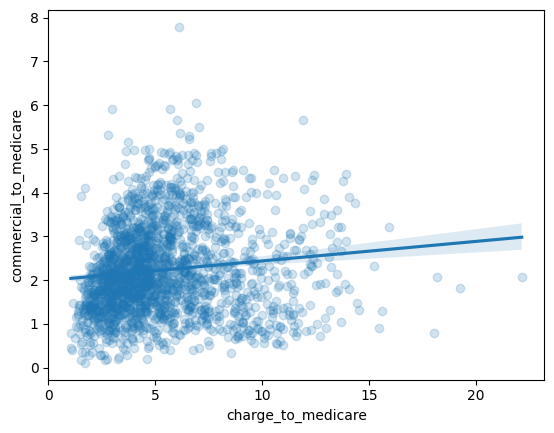

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.regplot(
    data=hosp,
    x="charge_to_medicare",
    y="commercial_to_medicare",
    scatter_kws={"alpha":0.2}
)

plt.show()

In [57]:
print(hosp[[
    "commercial_to_medicare",
    "ma_to_medicare",
    "charge_to_medicare"
]].corr())

                        commercial_to_medicare  ma_to_medicare  \
commercial_to_medicare                 1.00000        0.083860   
ma_to_medicare                         0.08386        1.000000   
charge_to_medicare                     0.11805        0.030984   

                        charge_to_medicare  
commercial_to_medicare            0.118050  
ma_to_medicare                    0.030984  
charge_to_medicare                1.000000  


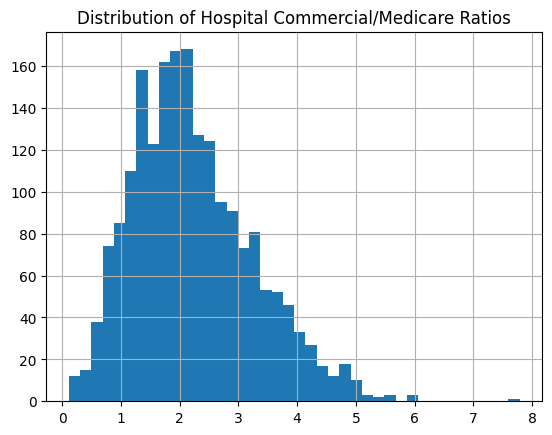

In [58]:
hosp["commercial_to_medicare"].hist(bins=40)
plt.title("Distribution of Hospital Commercial/Medicare Ratios")
plt.show()

In [59]:
import statsmodels.api as sm

X = hosp[["charge_to_medicare"]]
X = sm.add_constant(X)

y = hosp["commercial_to_medicare"]

model = sm.OLS(y, X).fit()
print(model.summary())

                              OLS Regression Results                              
Dep. Variable:     commercial_to_medicare   R-squared:                       0.014
Model:                                OLS   Adj. R-squared:                  0.013
Method:                     Least Squares   F-statistic:                     28.00
Date:                    Wed, 04 Mar 2026   Prob (F-statistic):           1.35e-07
Time:                            16:46:53   Log-Likelihood:                -2846.2
No. Observations:                    1983   AIC:                             5696.
Df Residuals:                        1981   BIC:                             5708.
Df Model:                               1                                         
Covariance Type:                nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------

In [60]:
import pandas as pd

data_path = r"C:\Users\priva\OneDrive\Documents\Honors Project\Data"
merged_file = data_path + r"\thesis_merged_with_turquoise.csv"

merged = pd.read_csv(merged_file, dtype={"CCN": str}, low_memory=False)

# make sure CCN is 6-digit string
merged["CCN"] = merged["CCN"].str.zfill(6)

# pick a state column that exists (use Medicare state if present; fallback to Turquoise state)
state_col = None
for c in ["Rndrng_Prvdr_State_Abrvtn", "PROVIDER_STATE", "State", "STATE"]:
    if c in merged.columns:
        state_col = c
        break

print("state_col_used:", state_col)

# CCN -> state (take first non-null per CCN)
ccn_state = (
    merged[["CCN", state_col]]
    .dropna()
    .drop_duplicates(subset=["CCN"])
    .rename(columns={state_col: "STATE"})
)

# make sure hosp CCN is formatted same way
hosp["CCN"] = hosp["CCN"].astype(str).str.zfill(6)

# attach state
hosp = hosp.merge(ccn_state, on="CCN", how="left")

print(hosp.columns)
print(hosp["STATE"].isna().mean())

state_col_used: Rndrng_Prvdr_State_Abrvtn
Index(['CCN', 'commercial_to_medicare', 'ma_to_medicare', 'charge_to_medicare',
       'STATE'],
      dtype='object')
0.0


In [61]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

# make sure the key columns are numeric
hosp["commercial_to_medicare"] = pd.to_numeric(hosp["commercial_to_medicare"], errors="coerce")
hosp["charge_to_medicare"] = pd.to_numeric(hosp["charge_to_medicare"], errors="coerce")
hosp["STATE"] = hosp["STATE"].astype(str)

# build X with state fixed effects
state_dummies = pd.get_dummies(hosp["STATE"], drop_first=True, dtype=float)

X = pd.concat([hosp[["charge_to_medicare"]], state_dummies], axis=1)
X = sm.add_constant(X)

y = hosp["commercial_to_medicare"]

# drop rows with any missing after coercion
df = pd.concat([y, X], axis=1).dropna()
y2 = df["commercial_to_medicare"]
X2 = df.drop(columns=["commercial_to_medicare"]).astype(float)

m = sm.OLS(y2, X2).fit()
m_robust = m.get_robustcov_results(cov_type="HC1")

print(m_robust.summary())
print("n used:", int(m_robust.nobs))

                              OLS Regression Results                              
Dep. Variable:     commercial_to_medicare   R-squared:                       0.179
Model:                                OLS   Adj. R-squared:                  0.158
Method:                     Least Squares   F-statistic:                     69.46
Date:                    Wed, 04 Mar 2026   Prob (F-statistic):               0.00
Time:                            16:46:57   Log-Likelihood:                -2664.8
No. Observations:                    1983   AIC:                             5432.
Df Residuals:                        1932   BIC:                             5717.
Df Model:                              50                                         
Covariance Type:                      HC1                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------

In [62]:
hosp["log_comm"] = np.log(hosp["commercial_to_medicare"])
hosp["log_charge"] = np.log(hosp["charge_to_medicare"])

state_dummies = pd.get_dummies(hosp["STATE"], drop_first=True, dtype=float)

X = pd.concat([hosp[["log_charge"]], state_dummies], axis=1)
X = sm.add_constant(X)

y = hosp["log_comm"]

df = pd.concat([y, X], axis=1).dropna()

m = sm.OLS(df["log_comm"], df.drop(columns=["log_comm"])).fit(cov_type="HC1")

print(m.summary())

                            OLS Regression Results                            
Dep. Variable:               log_comm   R-squared:                       0.198
Model:                            OLS   Adj. R-squared:                  0.177
Method:                 Least Squares   F-statistic:                     103.9
Date:                Wed, 04 Mar 2026   Prob (F-statistic):               0.00
Time:                        16:46:57   Log-Likelihood:                -1286.0
No. Observations:                1983   AIC:                             2674.
Df Residuals:                    1932   BIC:                             2959.
Df Model:                          50                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2210      0.356      0.621      0.5

In [63]:
hosp[["commercial_to_medicare",
      "ma_to_medicare",
      "charge_to_medicare"]].corr()

,commercial_to_medicare,ma_to_medicare,charge_to_medicare
commercial_to_medicare,1.00000,0.083860,0.118050
ma_to_medicare,0.08386,1.000000,0.030984
charge_to_medicare,0.11805,0.030984,1.000000


In [64]:
import numpy as np
import statsmodels.api as sm

# check what's broken
cols = ["commercial_to_medicare", "ma_to_medicare", "charge_to_medicare"]
print(hosp[cols].isna().sum())

print("inf counts")
for c in cols:
    print(c, np.isinf(hosp[c]).sum())

# keep only usable rows
df = hosp[cols].replace([np.inf, -np.inf], np.nan).dropna()

print("n used:", len(df))

X = sm.add_constant(df[["ma_to_medicare", "charge_to_medicare"]])
y = df["commercial_to_medicare"]

m = sm.OLS(y, X).fit(cov_type="HC1")
print(m.summary())

commercial_to_medicare      0
ma_to_medicare            231
charge_to_medicare          0
dtype: int64
inf counts
commercial_to_medicare 0
ma_to_medicare 0
charge_to_medicare 0
n used: 1752
                              OLS Regression Results                              
Dep. Variable:     commercial_to_medicare   R-squared:                       0.022
Model:                                OLS   Adj. R-squared:                  0.021
Method:                     Least Squares   F-statistic:                     13.01
Date:                    Wed, 04 Mar 2026   Prob (F-statistic):           2.47e-06
Time:                            16:46:57   Log-Likelihood:                -2505.8
No. Observations:                    1752   AIC:                             5018.
Df Residuals:                        1749   BIC:                             5034.
Df Model:                               2                                         
Covariance Type:                      HC1                      

In [65]:
DATA_PATH = r"C:\Users\priva\OneDrive\Documents\Honors Project\Data"

WORKING = os.path.join(DATA_PATH, "thesis_working_dataset.csv")
MERGED = os.path.join(DATA_PATH, "thesis_merged_with_turquoise.csv")

df = pd.read_csv(MERGED, low_memory=False)

# Keys
df["CCN"] = df["CCN"].astype(str).str.replace(r"\.0$", "", regex=True).str.zfill(6)
df["DRG_Cd"] = pd.to_numeric(df["DRG_Cd"], errors="coerce").astype("Int64")
df["Year"] = pd.to_numeric(df["Year"], errors="coerce").astype("Int64")

# Quality variables
df["rating_num"] = pd.to_numeric(df["Hospital overall rating"].replace("Not Available", np.nan), errors="coerce")
df["rating_available"] = df["rating_num"].notna().astype(int)

# Ensure numeric payment fields
num_cols = [
    "Tot_Dschrgs",
    "Avg_Submtd_Cvrd_Chrg",
    "Avg_Mdcr_Pymt_Amt",
    "AVG_COMMERCIAL",
    "AVG_MEDICARE_ADVANTAGE",
]
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Ratios (CMS Medicare payment as denominator)
den = df["Avg_Mdcr_Pymt_Amt"]
df["charge_to_medicare"] = df["Avg_Submtd_Cvrd_Chrg"] / den
df["commercial_to_medicare"] = df["AVG_COMMERCIAL"] / den
df["ma_to_medicare"] = df["AVG_MEDICARE_ADVANTAGE"] / den

# Gap between charges and commercial payment (level and ratio form)
df["gap_charge_comm_level"] = df["Avg_Submtd_Cvrd_Chrg"] - df["AVG_COMMERCIAL"]
df["gap_charge_comm_ratio"] = df["Avg_Submtd_Cvrd_Chrg"] / df["AVG_COMMERCIAL"]

# Basic validity filters
ratio_cols = ["charge_to_medicare", "commercial_to_medicare", "ma_to_medicare", "gap_charge_comm_ratio"]
for c in ratio_cols:
    df.loc[~np.isfinite(df[c]), c] = np.nan

df = df[df["Avg_Mdcr_Pymt_Amt"] > 0].copy()
df = df[df["Tot_Dschrgs"] > 0].copy()

# Hospital-level aggregation (weighted by Medicare discharges)
w = df["Tot_Dschrgs"]

def wavg(x, w):
    m = x.notna() & w.notna()
    if m.sum() == 0:
        return np.nan
    return np.average(x[m], weights=w[m])

group_cols = ["CCN"]
keep_first = [
    "Rndrng_Prvdr_Org_Name",
    "Rndrng_Prvdr_State_Abrvtn",
    "Rndrng_Prvdr_RUCA_Desc",
    "Hospital Type",
    "Hospital Ownership",
    "Emergency Services",
    "has_hosp_info",
]

agg = df.groupby(group_cols, dropna=False).apply(
    lambda g: pd.Series({
        "STATE": g["Rndrng_Prvdr_State_Abrvtn"].dropna().iloc[0] if g["Rndrng_Prvdr_State_Abrvtn"].notna().any() else np.nan,
        "Tot_Dschrgs_sum": g["Tot_Dschrgs"].sum(),
        "rating_num": g["rating_num"].dropna().iloc[0] if g["rating_num"].notna().any() else np.nan,
        "rating_available": int(g["rating_num"].notna().any()),
        "charge_to_medicare": wavg(g["charge_to_medicare"], g["Tot_Dschrgs"]),
        "commercial_to_medicare": wavg(g["commercial_to_medicare"], g["Tot_Dschrgs"]),
        "ma_to_medicare": wavg(g["ma_to_medicare"], g["Tot_Dschrgs"]),
        "gap_charge_comm_level": wavg(g["gap_charge_comm_level"], g["Tot_Dschrgs"]),
        "gap_charge_comm_ratio": wavg(g["gap_charge_comm_ratio"], g["Tot_Dschrgs"]),
        "has_turquoise": int(g["has_turquoise"].fillna(0).max()),
    })
).reset_index()

# Attach stable hospital descriptors (first non-missing per CCN)
meta = (
    df[["CCN"] + [c for c in keep_first if c in df.columns]]
    .sort_values(["CCN"])
    .groupby("CCN", as_index=False)
    .first()
)

hosp = agg.merge(meta, on="CCN", how="left")

OUT = os.path.join(DATA_PATH, "analysis_hospital_level_ready.csv")
hosp.to_csv(OUT, index=False)

print("Saved:", OUT)
print("Hospitals:", hosp.shape[0])
print(hosp[["charge_to_medicare", "commercial_to_medicare", "ma_to_medicare"]].describe().T)
print("Rating available:", hosp["rating_available"].mean())
print("Has turquoise:", hosp["has_turquoise"].mean())

C:\Users\priva\AppData\Local\Temp\ipykernel_13224\3454552025.py:67: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  agg = df.groupby(group_cols, dropna=False).apply(


Saved: C:\Users\priva\OneDrive\Documents\Honors Project\Data\analysis_hospital_level_ready.csv
Hospitals: 3369
                         count      mean        std       min       25%  \
charge_to_medicare      3369.0  4.851163   2.563739  0.283715  3.077503   
commercial_to_medicare  1994.0  2.628272   5.915489  0.031218  1.462016   
ma_to_medicare          1802.0  2.152842  10.249887  0.000152  1.211005   

                             50%       75%         max  
charge_to_medicare      4.328126  5.997648   21.471191  
commercial_to_medicare  2.092536  2.870820  131.270763  
ma_to_medicare          1.363224  1.510970  167.259334  
Rating available: 0.7491837340457109
Has turquoise: 0.5918670228554467


In [66]:
FILE = os.path.join(DATA_PATH, "analysis_hospital_level_ready.csv")

df = pd.read_csv(FILE)

# IQR outlier removal for ratio variables
ratio_cols = [
    "charge_to_medicare",
    "commercial_to_medicare",
    "ma_to_medicare",
    "gap_charge_comm_ratio"
]

for c in ratio_cols:
    q1 = df[c].quantile(0.25)
    q3 = df[c].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    df.loc[(df[c] < lower) | (df[c] > upper), c] = np.nan

# Keep hospitals with valid commercial ratio and rating
df_model = df[
    df["commercial_to_medicare"].notna() &
    df["rating_num"].notna()
].copy()

# Save cleaned dataset
OUT = os.path.join(DATA_PATH, "analysis_hospital_level_clean.csv")
df_model.to_csv(OUT, index=False)

print("Saved:", OUT)
print("N hospitals:", df_model.shape[0])
print(df_model[["charge_to_medicare","commercial_to_medicare","ma_to_medicare"]].describe().T)

Saved: C:\Users\priva\OneDrive\Documents\Honors Project\Data\analysis_hospital_level_clean.csv
N hospitals: 1702
                         count      mean       std       min       25%  \
charge_to_medicare      1583.0  4.909229  1.978207  0.899260  3.414476   
commercial_to_medicare  1702.0  2.217003  0.972685  0.031218  1.471674   
ma_to_medicare          1384.0  1.354311  0.212721  0.761296  1.230530   

                             50%       75%        max  
charge_to_medicare      4.509180  6.113835  10.357423  
commercial_to_medicare  2.125635  2.855960   4.942229  
ma_to_medicare          1.362349  1.492574   1.954689  


In [67]:
# rating as numeric
df["rating_num"] = pd.to_numeric(df["rating_num"], errors="coerce")

# baseline: rating ~ commercial_to_medicare
y = df["rating_num"]
X = sm.add_constant(df[["commercial_to_medicare"]])
m1 = sm.OLS(y, X, missing="drop").fit(cov_type="HC1")
m1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             rating_num   R-squared:                       0.043
Model:                            OLS   Adj. R-squared:                  0.042
Method:                 Least Squares   F-statistic:                     78.73
Date:                Wed, 04 Mar 2026   Prob (F-statistic):           1.77e-18
Time:                        16:47:33   Log-Likelihood:                -2519.0
No. Observations:                1702   AIC:                             5042.
Df Residuals:                    1700   BIC:                             5053.
Df Model:                           1                                         
Covariance Type:                  HC1                                         
==========================================================================================
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      2.5336      0.063     39.982      0.000       2.409       2.658
commercial_to_medicare     0.2305      0.026      8.873      0.000       0.180       0.281
==============================================================================
Omnibus:                       61.791   Durbin-Watson:                   1.826
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               28.381
Skew:                          -0.046   Prob(JB):                     6.87e-07
Kurtosis:                       2.374   Cond. No.                         6.91
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

In [68]:
# add charge inflation
X2 = sm.add_constant(df[["commercial_to_medicare", "charge_to_medicare"]])
m2 = sm.OLS(y, X2, missing="drop").fit(cov_type="HC1")
m2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             rating_num   R-squared:                       0.045
Model:                            OLS   Adj. R-squared:                  0.044
Method:                 Least Squares   F-statistic:                     37.93
Date:                Wed, 04 Mar 2026   Prob (F-statistic):           8.13e-17
Time:                        16:47:33   Log-Likelihood:                -2331.8
No. Observations:                1583   AIC:                             4670.
Df Residuals:                    1580   BIC:                             4686.
Df Model:                           2                                         
Covariance Type:                  HC1                                         
==========================================================================================
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      2.5765      0.090     28.521      0.000       2.399       2.754
commercial_to_medicare     0.2379      0.027      8.691      0.000       0.184       0.292
charge_to_medicare        -0.0035      0.014     -0.261      0.794      -0.030       0.023
==============================================================================
Omnibus:                       53.081   Durbin-Watson:                   1.869
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               25.449
Skew:                          -0.063   Prob(JB):                     2.98e-06
Kurtosis:                       2.392   Cond. No.                         19.9
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

In [69]:
# add ownership, type, emergency
controls = ["commercial_to_medicare", "charge_to_medicare"]

for c in ["Hospital Ownership", "Hospital Type", "Emergency Services"]:
    if c in df.columns:
        d = pd.get_dummies(df[c], drop_first=True, dtype=float)
        df = pd.concat([df, d], axis=1)
        controls += d.columns.tolist()

X3 = sm.add_constant(df[controls])
m3 = sm.OLS(y, X3, missing="drop").fit(cov_type="HC1")
m3.summary()

c:\Users\priva\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 12, but rank is 11
  warnings.warn('covariance of constraints does not have full '


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             rating_num   R-squared:                       0.074
Model:                            OLS   Adj. R-squared:                  0.067
Method:                 Least Squares   F-statistic:                     12.01
Date:                Wed, 04 Mar 2026   Prob (F-statistic):           6.25e-22
Time:                        16:47:33   Log-Likelihood:                -2307.4
No. Observations:                1583   AIC:                             4639.
Df Residuals:                    1571   BIC:                             4703.
Df Model:                          11                                         
Covariance Type:                  HC1                                         
===============================================================================================================
                                                  coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------
const                                           3.3796      0.493      6.850      0.000       2.413       4.347
commercial_to_medicare                          0.1955      0.029      6.815      0.000       0.139       0.252
charge_to_medicare                              0.0116      0.015      0.764      0.445      -0.018       0.041
Government - Hospital District or Authority    -0.7486      0.492     -1.523      0.128      -1.712       0.215
Government - Local                             -0.8993      0.501     -1.795      0.073      -1.881       0.083
Government - State                             -0.6660      0.522     -1.277      0.202      -1.688       0.356
Physician                                      -0.0007      0.587     -0.001      0.999      -1.151       1.150
Proprietary                                    -0.7825      0.487     -1.607      0.108      -1.737       0.172
Tribal                                      -4.904e-15   2.89e-15     -1.699      0.089   -1.06e-14    7.52e-16
Voluntary non-profit - Church                  -0.3381      0.488     -0.693      0.488      -1.295       0.618
Voluntary non-profit - Other                   -0.6003      0.488     -1.229      0.219      -1.557       0.357
Voluntary non-profit - Private                 -0.4123      0.482     -0.856      0.392      -1.356       0.532
Yes                                            -0.2691      0.123     -2.193      0.028      -0.510      -0.029
==============================================================================
Omnibus:                       46.732   Durbin-Watson:                   1.882
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               23.004
Skew:                          -0.039   Prob(JB):                     1.01e-05
Kurtosis:                       2.415   Cond. No.                     6.22e+17
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
[2] The smallest eigenvalue is 1.42e-31. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

In [70]:
# state fixed effects
state_d = pd.get_dummies(df["STATE"], drop_first=True, dtype=float)
X4 = pd.concat([df[["commercial_to_medicare", "charge_to_medicare"]], state_d], axis=1)
X4 = sm.add_constant(X4)

m4 = sm.OLS(y, X4, missing="drop").fit(cov_type="HC1")
m4.summary()

c:\Users\priva\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 52, but rank is 51
  warnings.warn('covariance of constraints does not have full '


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             rating_num   R-squared:                       0.165
Model:                            OLS   Adj. R-squared:                  0.137
Method:                 Least Squares   F-statistic:                     47.94
Date:                Wed, 04 Mar 2026   Prob (F-statistic):          7.79e-277
Time:                        16:47:33   Log-Likelihood:                -2225.6
No. Observations:                1583   AIC:                             4555.
Df Residuals:                    1531   BIC:                             4834.
Df Model:                          51                                         
Covariance Type:                  HC1                                         
==========================================================================================
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      2.2716      0.617      3.681      0.000       1.062       3.481
commercial_to_medicare     0.2298      0.030      7.642      0.000       0.171       0.289
charge_to_medicare         0.0040      0.016      0.247      0.805      -0.028       0.036
AL                        -0.1779      0.629     -0.283      0.777      -1.410       1.054
AR                        -0.2245      0.663     -0.339      0.735      -1.523       1.074
AZ                        -0.0044      0.620     -0.007      0.994      -1.219       1.210
CA                         0.3392      0.615      0.551      0.582      -0.867       1.545
CO                         0.7404      0.639      1.158      0.247      -0.512       1.993
CT                         0.2417      0.631      0.383      0.702      -0.996       1.479
DC                        -0.8550      0.707     -1.209      0.227      -2.240       0.531
DE                         0.7316      0.890      0.822      0.411      -1.012       2.476
FL                         0.1305      0.618      0.211      0.833      -1.081       1.342
GA                        -0.0490      0.641     -0.076      0.939      -1.306       1.208
HI                         0.4918      0.683      0.720      0.472      -0.847       1.831
IA                         0.1639      0.660      0.248      0.804      -1.130       1.458
ID                         0.9913      0.669      1.481      0.139      -0.321       2.303
IL                        -0.0107      0.625     -0.017      0.986      -1.236       1.214
IN                         0.1948      0.621      0.314      0.754      -1.022       1.411
KS                         0.8191      0.651      1.258      0.208      -0.457       2.096
KY                        -0.1285      0.627     -0.205      0.838      -1.358       1.101
LA                         0.2100      0.628      0.334      0.738      -1.021       1.441
MA                         0.0264      0.634      0.042      0.967      -1.215       1.268
MD                      6.565e-16   5.42e-16      1.211      0.226   -4.06e-16    1.72e-15
ME                        -0.5420      0.611     -0.888      0.375      -1.739       0.655
MI                         0.2569      0.626      0.410      0.682      -0.971       1.484
MN                         1.0978      0.627      1.750      0.080      -0.132       2.327
MO                         0.7476      0.623      1.200      0.230      -0.473       1.968
MS                        -0.3966      0.647     -0.613      0.540      -1.664       0.871
MT                         0.2696      0.761      0.354      0.723      -1.221       1.760
NC                         0.1810      0.626      0.289      0.773      -1.046       1.408
ND                         0.7056      0.747      0.944      0.345      -0.759  

In [71]:
df["commercial_to_medicare"].describe()

count    1969.000000
mean        2.200195
std         0.984391
min         0.031218
25%         1.449497
50%         2.083317
75%         2.833683
max         4.945444
Name: commercial_to_medicare, dtype: float64

In [72]:
df["high_quality"] = (df["rating_num"] >= 4).astype(int)

y = df["high_quality"]
X = sm.add_constant(df[["commercial_to_medicare", "charge_to_medicare"]])

logit = sm.Logit(y, X, missing="drop").fit(disp=False)
logit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:           high_quality   No. Observations:                 1843
Model:                          Logit   Df Residuals:                     1840
Method:                           MLE   Df Model:                            2
Date:                Wed, 04 Mar 2026   Pseudo R-squ.:                 0.02345
Time:                        16:47:34   Log-Likelihood:                -1125.4
converged:                       True   LL-Null:                       -1152.5
Covariance Type:            nonrobust   LLR p-value:                 1.835e-12
==========================================================================================
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -1.7219      0.170    -10.124      0.000      -2.055      -1.389
commercial_to_medicare     0.3631      0.052      6.954      0.000       0.261       0.465
charge_to_medicare         0.0279      0.026      1.068      0.285      -0.023       0.079
==========================================================================================
"""

In [73]:
marg = logit.get_margeff()
marg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
        Logit Marginal Effects       
=====================================
Dep. Variable:           high_quality
Method:                          dydx
At:                           overall
==========================================================================================
                            dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
commercial_to_medicare     0.0764      0.010      7.297      0.000       0.056       0.097
charge_to_medicare         0.0059      0.005      1.069      0.285      -0.005       0.017
==========================================================================================
"""

In [74]:
tmp = df[["STATE", "high_quality", "commercial_to_medicare", "charge_to_medicare"]].dropna()

g = tmp.groupby("STATE")["high_quality"].agg(["count", "sum"])
g["mean"] = g["sum"] / g["count"]
g["var_ok"] = (g["sum"] > 0) & (g["sum"] < g["count"])

g.sort_values(["var_ok", "count", "mean"]).head(20), g["var_ok"].value_counts()

(       count  sum      mean  var_ok
 STATE                              
 ME         1    0  0.000000   False
 DC         5    0  0.000000   False
 DE         3    1  0.333333    True
 MT         3    1  0.333333    True
 VT         4    1  0.250000    True
 RI         4    2  0.500000    True
 ND         4    3  0.750000    True
 AK         5    1  0.200000    True
 WY         6    1  0.166667    True
 NH         9    4  0.444444    True
 HI        10    4  0.400000    True
 SD        10    7  0.700000    True
 NV        12    2  0.166667    True
 ID        12    6  0.500000    True
 NM        13    1  0.076923    True
 WV        16    1  0.062500    True
 CT        17    4  0.235294    True
 NE        17    5  0.294118    True
 OR        19    7  0.368421    True
 AR        20    3  0.150000    True,
 var_ok
 True     48
 False     2
 Name: count, dtype: int64)

In [75]:
keep_states = g.index[g["var_ok"]].tolist()

d = tmp[tmp["STATE"].isin(keep_states)].copy()
state_d = pd.get_dummies(d["STATE"], drop_first=True, dtype=float)

X_fe = pd.concat([d[["commercial_to_medicare", "charge_to_medicare"]], state_d], axis=1)
X_fe = sm.add_constant(X_fe)

logit_fe = sm.Logit(d["high_quality"], X_fe).fit(disp=False)
logit_fe.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:           high_quality   No. Observations:                 1837
Model:                          Logit   Df Residuals:                     1787
Method:                           MLE   Df Model:                           49
Date:                Wed, 04 Mar 2026   Pseudo R-squ.:                 0.08724
Time:                        16:47:34   Log-Likelihood:                -1049.8
converged:                       True   LL-Null:                       -1150.2
Covariance Type:            nonrobust   LLR p-value:                 2.969e-20
==========================================================================================
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -2.5041      1.134     -2.208      0.027      -4.727      -0.281
commercial_to_medicare     0.3668      0.060      6.104      0.000       0.249       0.485
charge_to_medicare         0.0712      0.032      2.198      0.028       0.008       0.135
AL                        -1.4323      1.336     -1.072      0.284      -4.050       1.186
AR                        -0.1978      1.285     -0.154      0.878      -2.716       2.321
AZ                        -0.5046      1.188     -0.425      0.671      -2.833       1.824
CA                         0.7074      1.135      0.623      0.533      -1.517       2.932
CO                         1.0163      1.173      0.867      0.386      -1.282       3.315
CT                         0.2017      1.259      0.160      0.873      -2.265       2.668
DE                         0.4978      1.670      0.298      0.766      -2.775       3.770
FL                         0.5796      1.141      0.508      0.612      -1.657       2.816
GA                         0.2117      1.166      0.182      0.856      -2.074       2.497
HI                         1.1793      1.294      0.911      0.362      -1.357       3.715
IA                         0.4406      1.204      0.366      0.714      -1.919       2.800
ID                         1.1775      1.262      0.933      0.351      -1.296       3.651
IL                         0.3879      1.156      0.336      0.737      -1.877       2.653
IN                         0.0873      1.163      0.075      0.940      -2.192       2.367
KS                         1.1623      1.185      0.981      0.327      -1.161       3.485
KY                        -0.1605      1.186     -0.135      0.892      -2.485       2.164
LA                         0.0056      1.195      0.005      0.996      -2.337       2.348
MA                         0.2162      1.249      0.173      0.863      -2.232       2.664
MI                         0.9664      1.158      0.834      0.404      -1.304       3.237
MN                         1.9968      1.166      1.712      0.087      -0.289       4.283
MO                         1.6713      1.176      1.422      0.155      -0.633       3.975
MS                        -0.9568      1.343     -0.713      0.476      -3.588       1.675
MT                         0.8369      1.665      0.503      0.615      -2.426       4.099
NC                         0.3008      1.161      0.259      0.796      -1.975       2.576
ND                         2.5678      1.609      1.596      0.111      -0.586       5.721
NE                         0.2894      1.241      0.233      0.816      -2.144       2.723
NH                         1.2785      1.308      0.977      0.328      -1.285       3.842
NJ                        -0.0717      1.176     -0.061      0.951      -2.376       2.233
NM                        -0.9314      1.531     -0.608      0.543      -3.933       2.070
NV                        -0.6642      1.374     -0.483 

In [76]:
logit_fe.get_margeff().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
        Logit Marginal Effects       
=====================================
Dep. Variable:           high_quality
Method:                          dydx
At:                           overall
==========================================================================================
                            dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
commercial_to_medicare     0.0714      0.011      6.331      0.000       0.049       0.093
charge_to_medicare         0.0139      0.006      2.207      0.027       0.002       0.026
AL                        -0.2787      0.260     -1.073      0.283      -0.788       0.231
AR                        -0.0385      0.250     -0.154      0.878      -0.528       0.451
AZ                        -0.0982      0.231     -0.425      0.671      -0.551       0.355
CA                         0.1376      0.221      0.623      0.533      -0.295       0.570
CO                         0.1977      0.228      0.867      0.386      -0.249       0.645
CT                         0.0392      0.245      0.160      0.873      -0.441       0.519
DE                         0.0968      0.325      0.298      0.766      -0.540       0.733
FL                         0.1128      0.222      0.508      0.611      -0.322       0.548
GA                         0.0412      0.227      0.182      0.856      -0.403       0.486
HI                         0.2294      0.252      0.912      0.362      -0.264       0.722
IA                         0.0857      0.234      0.366      0.714      -0.373       0.545
ID                         0.2291      0.245      0.934      0.350      -0.252       0.710
IL                         0.0755      0.225      0.336      0.737      -0.365       0.516
IN                         0.0170      0.226      0.075      0.940      -0.426       0.460
KS                         0.2261      0.230      0.982      0.326      -0.225       0.678
KY                        -0.0312      0.231     -0.135      0.892      -0.483       0.421
LA                         0.0011      0.233      0.005      0.996      -0.455       0.457
MA                         0.0421      0.243      0.173      0.863      -0.434       0.518
MI                         0.1880      0.225      0.835      0.404      -0.253       0.629
MN                         0.3885      0.226      1.717      0.086      -0.055       0.832
MO                         0.3251      0.228      1.424      0.154      -0.122       0.773
MS                        -0.1861      0.261     -0.713      0.476      -0.698       0.326
MT                         0.1628      0.324      0.503      0.615      -0.472       0.797
NC                         0.0585      0.226      0.259      0.796      -0.384       0.501
ND                         0.4996      0.312      1.600      0.110      -0.112       1.111
NE                         0.0563      0.242      0.233      0.816      -0.417       0.530
NH                         0.2487      0.254      0.978      0.328      -0.250       0.747
NJ                        -0.0140      0.229     -0.061      0.951      -0.462       0.434
NM                        -0.1812      0.298     -0.608      0.543      -0.765       0.403
NV                        -0.1292      0.267     -0.484      0.629      -0.653       0.395
NY                        -0.0471      0.224     -0.211      0.833      -0.485       0.391
OH                         0.1960      0.225      0.872      0.383      -0.245       0.637
OK                         0.2102      0.230      0.916      0.360      -0.240       0.660
OR                         0.1553      0.237      0.655      0.512      -0.309       0.620
PA                         0.1473      0.221      0.666      0.505      -0.286       0.581
RI                         0.3228      0.292      1.106      0.269      -0.249       0.895
SC                         0.09

In [77]:
df["log_comm"] = np.log(df["commercial_to_medicare"])

y = df["rating_num"]
X = sm.add_constant(df[["log_comm", "charge_to_medicare"]])

m_log = sm.OLS(y, X, missing="drop").fit(cov_type="HC1")
m_log.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             rating_num   R-squared:                       0.043
Model:                            OLS   Adj. R-squared:                  0.042
Method:                 Least Squares   F-statistic:                     37.96
Date:                Wed, 04 Mar 2026   Prob (F-statistic):           7.90e-17
Time:                        16:47:34   Log-Likelihood:                -2332.9
No. Observations:                1583   AIC:                             4672.
Df Residuals:                    1580   BIC:                             4688.
Df Model:                           2                                         
Covariance Type:                  HC1                                         
======================================================================================
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  2.7841      0.079     35.398      0.000       2.630       2.938
log_comm               0.4434      0.051      8.705      0.000       0.344       0.543
charge_to_medicare    -0.0003      0.014     -0.021      0.984      -0.027       0.026
==============================================================================
Omnibus:                       55.883   Durbin-Watson:                   1.869
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               26.431
Skew:                          -0.068   Prob(JB):                     1.82e-06
Kurtosis:                       2.382   Cond. No.                         16.7
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

In [78]:
y = df["rating_num"]
X = sm.add_constant(df[["ma_to_medicare", "charge_to_medicare"]])

m_ma = sm.OLS(y, X, missing="drop").fit(cov_type="HC1")
m_ma.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             rating_num   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.1603
Date:                Wed, 04 Mar 2026   Prob (F-statistic):              0.852
Time:                        16:47:35   Log-Likelihood:                -1966.8
No. Observations:                1319   AIC:                             3940.
Df Residuals:                    1316   BIC:                             3955.
Df Model:                           2                                         
Covariance Type:                  HC1                                         
======================================================================================
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  2.9726      0.197     15.071      0.000       2.586       3.359
ma_to_medicare         0.0699      0.143      0.488      0.625      -0.211       0.350
charge_to_medicare     0.0030      0.015      0.196      0.844      -0.027       0.033
==============================================================================
Omnibus:                       63.319   Durbin-Watson:                   1.808
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               26.166
Skew:                          -0.039   Prob(JB):                     2.08e-06
Kurtosis:                       2.314   Cond. No.                         44.4
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

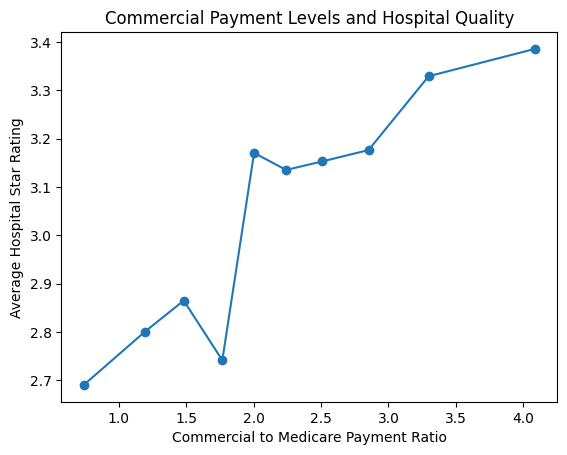

In [80]:
d = df[["commercial_to_medicare","rating_num"]].dropna().copy()
d["bin"] = pd.qcut(d["commercial_to_medicare"],10,duplicates="drop")

b = d.groupby("bin",observed=True).agg(
    mid=("commercial_to_medicare","mean"),
    mean_rating=("rating_num","mean")
).reset_index(drop=True)

plt.figure()
plt.plot(b["mid"],b["mean_rating"],marker="o")
plt.xlabel("Commercial to Medicare Payment Ratio")
plt.ylabel("Average Hospital Star Rating")
plt.title("Commercial Payment Levels and Hospital Quality")
plt.show()

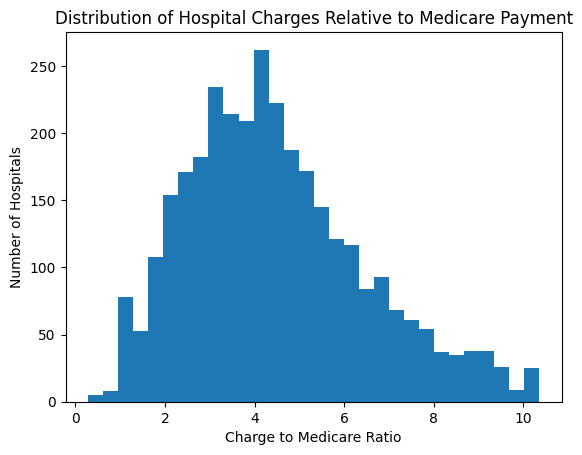

In [81]:
x = df["charge_to_medicare"].dropna()

plt.figure()
plt.hist(x,bins=30)
plt.xlabel("Charge to Medicare Ratio")
plt.ylabel("Number of Hospitals")
plt.title("Distribution of Hospital Charges Relative to Medicare Payment")
plt.show()

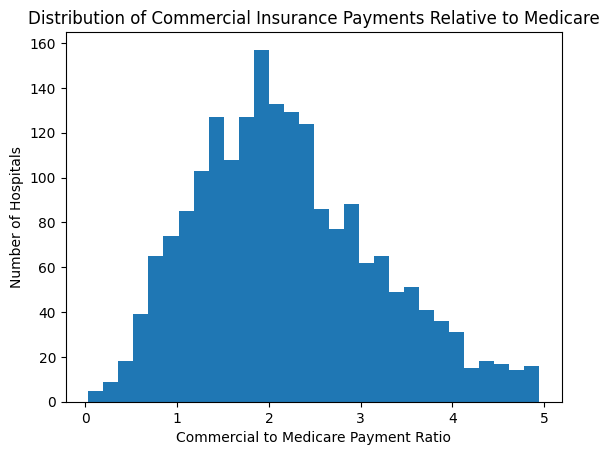

In [82]:
x = df["commercial_to_medicare"].dropna()

plt.figure()
plt.hist(x,bins=30)
plt.xlabel("Commercial to Medicare Payment Ratio")
plt.ylabel("Number of Hospitals")
plt.title("Distribution of Commercial Insurance Payments Relative to Medicare")
plt.show()

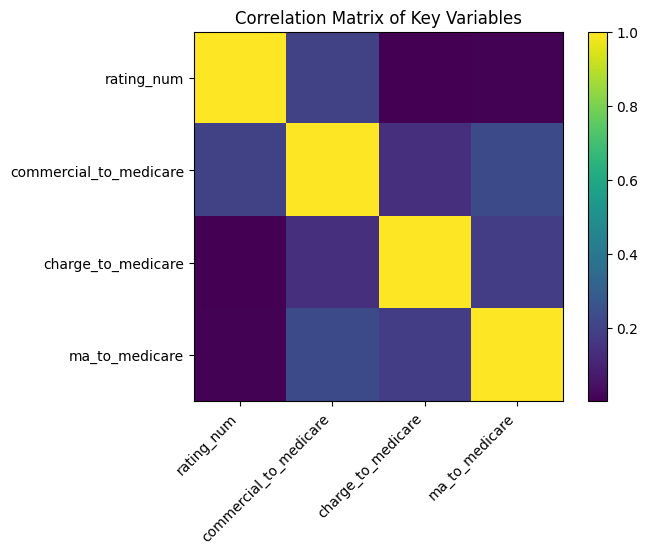

In [83]:
cols=["rating_num","commercial_to_medicare","charge_to_medicare","ma_to_medicare"]
c=df[cols].dropna().corr()

plt.figure()
plt.imshow(c.values)
plt.xticks(range(len(cols)),cols,rotation=45,ha="right")
plt.yticks(range(len(cols)),cols)
plt.colorbar()
plt.title("Correlation Matrix of Key Variables")
plt.show()

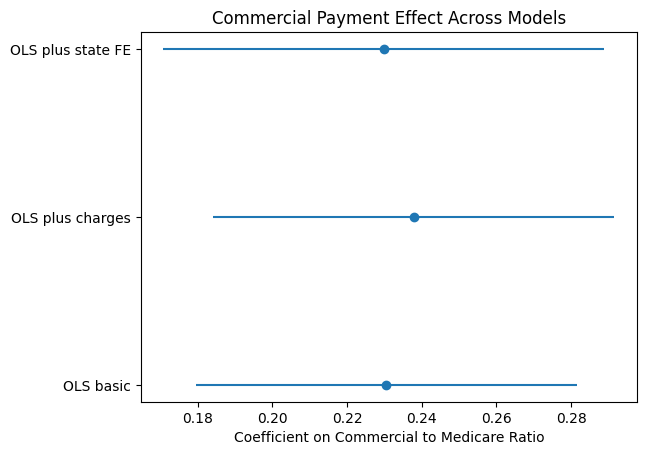

In [85]:
rows=[]
def add(model,label):
    b=model.params["commercial_to_medicare"]
    se=model.bse["commercial_to_medicare"]
    rows.append((label,b,b-1.96*se,b+1.96*se))

add(m1,"OLS basic")
add(m2,"OLS plus charges")
add(m4,"OLS plus state FE")

coef=pd.DataFrame(rows,columns=["model","b","lo","hi"])
ypos=np.arange(coef.shape[0])

plt.figure()
plt.hlines(ypos,coef["lo"],coef["hi"])
plt.plot(coef["b"],ypos,marker="o",linestyle="None")
plt.yticks(ypos,coef["model"])
plt.xlabel("Coefficient on Commercial to Medicare Ratio")
plt.title("Commercial Payment Effect Across Models")
plt.show()

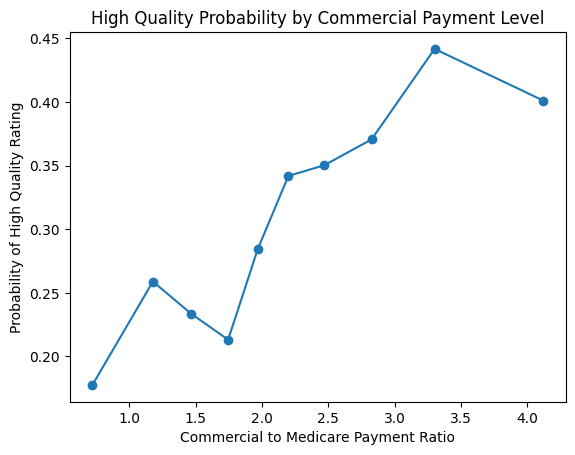

In [87]:
d=df[["commercial_to_medicare","high_quality"]].dropna().copy()
d["bin"]=pd.qcut(d["commercial_to_medicare"],10,duplicates="drop")

b=d.groupby("bin",observed=True).agg(
    mid=("commercial_to_medicare","mean"),
    p_high=("high_quality","mean")
).reset_index(drop=True)

plt.figure()
plt.plot(b["mid"],b["p_high"],marker="o")
plt.xlabel("Commercial to Medicare Payment Ratio")
plt.ylabel("Probability of High Quality Rating")
plt.title("High Quality Probability by Commercial Payment Level")
plt.show()